# Домашнє завдання: Візуалізація даних з Pandas

## Опис завдання
У цьому домашньому завданні ви працюватимете з датасетом про оренду велосипедів `yulu_rental.csv`. Датасет містить інформацію про кількість орендованих велосипедів залежно від погодних умов, сезону та інших факторів.
Набір даних взяти з Kaggle. Посилання на оригінальний [опис](https://www.kaggle.com/datasets/ranitsarkar01/yulu-bike-sharing-data?select=yulu_bike_sharing_dataset.csv).

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - відчувається як температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів



---
🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.


Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)

## Підготовка даних


In [171]:
import pandas as pd
import matplotlib.pyplot as plt

# Завантаження даних
df = pd.read_csv('yulu_bike_sharing_dataset.csv')

In [172]:
# Перетворення datetime у правильний формат
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Додамо додаткові колонки для аналізу
df['date'] = df.index.date
df['day'] = df.index.day
df['week'] = df.index.isocalendar().week
df['weekday_num'] = df.index.weekday
df['weekday'] = df.index.day_name()
df['year'] = df.index.year
df['month'] = df.index.month
df['hour'] = df.index.hour

## Завдання 0: Перегляд даних
**Завдання:**
Перегляньте дані, їх розмір, та напишіть висновок:
- скільки даних в наборі
- який рівень деталізації мають ці дані, тобто за який період міститься дані в одному рядку даних ?

In [173]:
df
# У цьому наборі даних 10886 рядків. Кожен рядок містить дані, отримані о певній годині.

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,date,day,week,weekday_num,weekday,year,month,hour
datetime,,,,,,,,,,,,,,,,,,,
2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0000,3,13,16,2011-01-01,1,52,5,Saturday,2011,1,0
2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0000,8,32,40,2011-01-01,1,52,5,Saturday,2011,1,1
2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0000,5,27,32,2011-01-01,1,52,5,Saturday,2011,1,2
2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0000,3,10,13,2011-01-01,1,52,5,Saturday,2011,1,3
2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0000,0,1,1,2011-01-01,1,52,5,Saturday,2011,1,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2012-12-19 19:00:00,4,0,1,1,15.58,19.695,50,26.0027,7,329,336,2012-12-19,19,51,2,Wednesday,2012,12,19
2012-12-19 20:00:00,4,0,1,1,14.76,17.425,57,15.0013,10,231,241,2012-12-19,19,51,2,Wednesday,2012,12,20
2012-12-19 21:00:00,4,0,1,1,13.94,15.910,61,15.0013,4,164,168,2012-12-19,19,51,2,Wednesday,2012,12,21


## Завдання 1: Базовий лінійний графік

**Завдання:**
1. Згрупуйте дані про кількість орендованих велосипедів (`count`) поденно.
2. Побудуйте з методом `DataFrame.plot()` лінійний графік поденної кількості орендованих велосипедів (`count`) за весь період в даних.
3. Налаштуйте розмір графіка (12x6), додайте заголовок "Динаміка оренди велосипедів" та сітку.
4. Дайте відповіді на питання по цьому графіку. Якщо треба - проведіть додаткові програмні операції для відповідей.

**Питання для інтерпретації:**
1. Як гадаєте, чому графік має "заломи", чим це спричинено і як ви б могли прибрати заломи?
2. Які загальні тенденції ви бачите на графіку?
3. Чи помітні якісь сезонні коливання?
4. Чи є періоди з аномально високими або низькими значеннями і чому на ваш погляд можуть бути ці аномалії?


In [174]:
count_rented_bikes_by_day = df['count'].resample('D').sum()
count_rented_bikes_by_day

datetime
2011-01-01     985
2011-01-02     801
2011-01-03    1349
2011-01-04    1562
2011-01-05    1600
              ... 
2012-12-15    5047
2012-12-16    3786
2012-12-17    4585
2012-12-18    5557
2012-12-19    5267
Freq: D, Name: count, Length: 719, dtype: int64

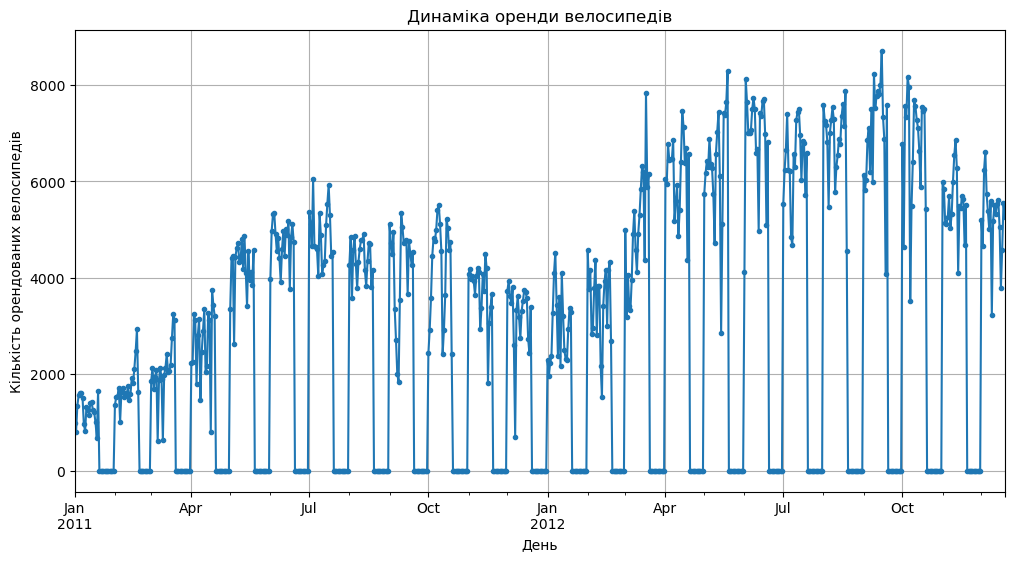

In [175]:
count_rented_bikes_by_day.plot(
    kind='line',
    marker='.',
    figsize=(12, 6),
    title='Динаміка оренди велосипедів',
    xlabel='День',
    ylabel='Кількість орендованих велосипедів',
    grid=True
);

In [176]:
count_rented_bikes_by_month = df['count'].resample('ME').sum()
count_rented_bikes_by_month

datetime
2011-01-31     23552
2011-02-28     32844
2011-03-31     38735
2011-04-30     50517
2011-05-31     79713
2011-06-30     89776
2011-07-31     92848
2011-08-31     83296
2011-09-30     79104
2011-10-31     79522
2011-11-30     70889
2011-12-31     61183
2012-01-31     56332
2012-02-29     66269
2012-03-31     94766
2012-04-30    116885
2012-05-31    120434
2012-06-30    130957
2012-07-31    121769
2012-08-31    130220
2012-09-30    133425
2012-10-31    127912
2012-11-30    105551
2012-12-31     98977
Freq: ME, Name: count, dtype: int64

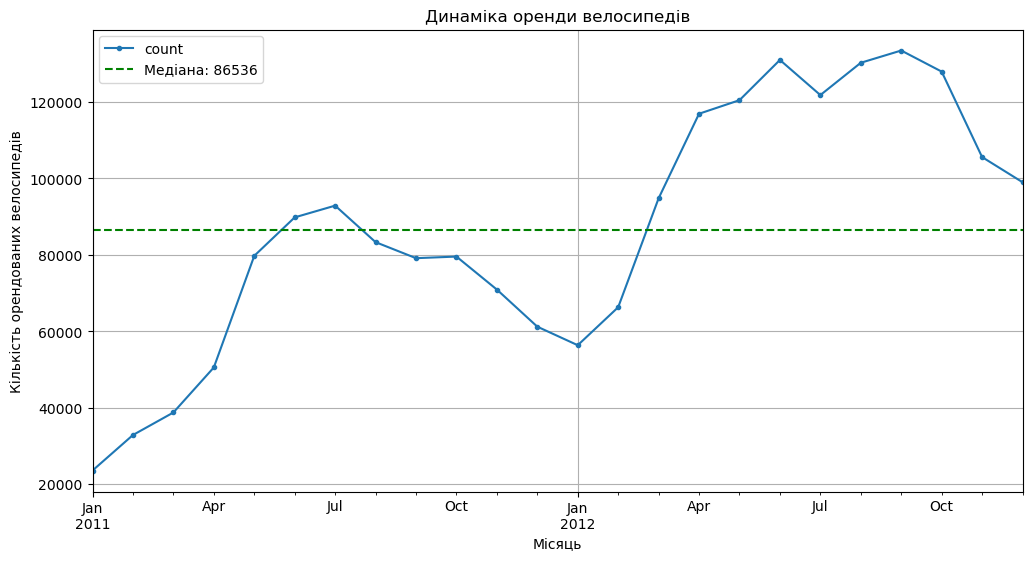

In [177]:
count_rented_bikes_by_month.plot(
    kind='line',
    marker='.',
    figsize=(12, 6),
    title='Динаміка оренди велосипедів',
    xlabel='Місяць',
    ylabel='Кількість орендованих велосипедів',
    grid=True
)

median_value = count_rented_bikes_by_month.median()

plt.axhline(
    y=median_value,
    color='green',
    linestyle='--',
    label=f"Медіана: {median_value:.0f}"
    )

plt.legend()

1. Як гадаєте, чому графік має "заломи", чим це спричинено і як ви б могли прибрати заломи?
Графік має "заломи", тому що дані поденні і різко змінюються в кожній наступній точці. Щоб припрати ці заломи, я загрегувала дані помісячно.
2. Які загальні тенденції ви бачите на графіку?
У 2012 році значно зросла кількість орендованих велосипедів, порівняно з 2011.
3. Чи помітні якісь сезонні коливання?
Показники починають стрімко зростати з середини весни, досягають піку влітку (2011 і 2012 рік) та восени (лише 2012 рік), ближче до зими йдуть на спад.
4. Чи є періоди з аномально високими або низькими значеннями і чому на ваш погляд можуть бути ці аномалії?
Аномально низькі значення в січні 2011 року, а аномально високі - у червні та вересні 2012 року. Я думаю, що це пов'язано з погодою. Коли дуже холодно, менше людей їздять на велосипедах, а коли тепло - навпаки більше. 


## Завдання 2: Аналіз сезонності (Bar Plot)

**Завдання:**
Побудуйте вертикальну стовпчасту діаграму середньої кількості орендованих велосипедів за сезонами(кварталами). Додайте підписи осей і заголовок.

Просунуте доповнення:
1. Позначте квартали не числом, а назвою на візуалізації.
2. Додайте підписи над стовпцями зі значеннями в кожному стовпці.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В який квартал найбільша середня кількість оренди велосипедів?
2. Як ви можете пояснити таку сезонну закономірність?
3. У скільки разів відрізняється оренда між найпопулярнішим та найменш популярним кварталми?

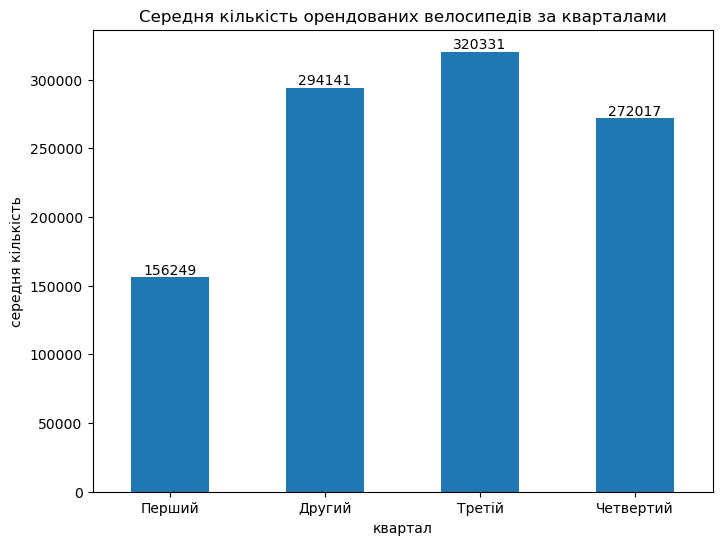

In [178]:
quarterly_sum = df['count'].resample('QE').sum()
avg_by_quarter = quarterly_sum.groupby(quarterly_sum.index.quarter).mean()

ax = quarterly_sum.groupby(quarterly_sum.index.quarter).mean().plot.bar(
    rot=0,
    figsize=(8, 6),
    title='Середня кількість орендованих велосипедів за кварталами',
    xlabel='квартал',
    ylabel='середня кількість',
)

ax.set_xticklabels(['Перший', 'Другий', 'Третій', 'Четвертий'])

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f');

1. В який квартал найбільша середня кількість оренди велосипедів? Найбільша середня кількість оренди велосипедів в третьому кварталі.
2. Як ви можете пояснити таку сезонну закономірність? Це може бути пов'язано з теплою погодою і довгим світловим днем, періодом канікул у дітей / відпусток у багатьох дорослих.
3. У скільки разів відрізняється оренда між найпопулярнішим та найменш популярним кварталами? У 2 рази.

## Завдання 3: Динаміка за місяцями (Line Plot)

**Завдання:**
Створіть лінійний графік середньої кількості оренди велосипедів по місяцях (тобто групування в рамках місяця і беремо середню кількість оренд в цей місяць з кількох років). Використайте маркери-кружечки для точок, додайте сітку та пофарбуйте лінію у червоний колір.

Просунуте доповнення:
- додайте аби по осі ОХ поділки були чітко на кожен окремий місяць по одній. Тобто сумарно 12 поділок.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В які місяці спостерігається пік та спад оренди?
2. Чи збігається ця закономірність з результатами з попереднього завдання?
3. Як може вплинути клімат на оренду велосипедів протягом року?


In [179]:
sum_rented_bikes_by_month_for_a_few_years = (df['count'].resample('ME').sum())
sum_rented_bikes_by_month_for_a_few_years

datetime
2011-01-31     23552
2011-02-28     32844
2011-03-31     38735
2011-04-30     50517
2011-05-31     79713
2011-06-30     89776
2011-07-31     92848
2011-08-31     83296
2011-09-30     79104
2011-10-31     79522
2011-11-30     70889
2011-12-31     61183
2012-01-31     56332
2012-02-29     66269
2012-03-31     94766
2012-04-30    116885
2012-05-31    120434
2012-06-30    130957
2012-07-31    121769
2012-08-31    130220
2012-09-30    133425
2012-10-31    127912
2012-11-30    105551
2012-12-31     98977
Freq: ME, Name: count, dtype: int64

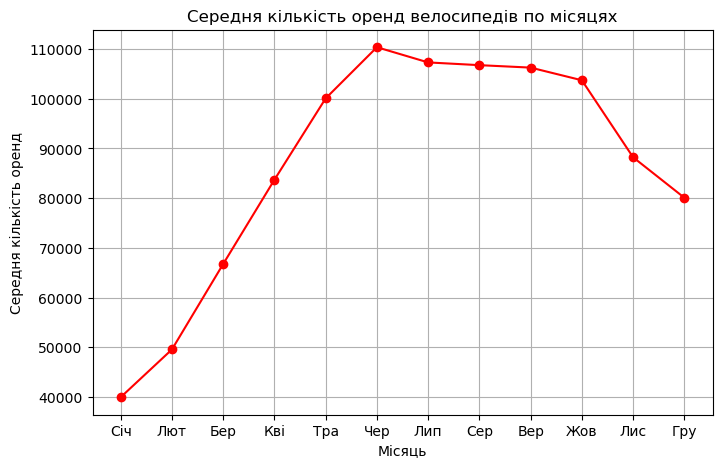

In [180]:
avg_rented_bikes_by_month_for_a_few_years = sum_rented_bikes_by_month_for_a_few_years.groupby(sum_rented_bikes_by_month_for_a_few_years.index.month).mean()
avg_rented_bikes_by_month_for_a_few_years

plt.figure(figsize=(8,5))

plt.plot(
    avg_rented_bikes_by_month_for_a_few_years.index,
    avg_rented_bikes_by_month_for_a_few_years.values,
    marker='o',
    color='red'
)

plt.title('Середня кількість оренд велосипедів по місяцях')
plt.xlabel('Місяць')
plt.ylabel('Середня кількість оренд')
plt.xticks(ticks=range(1, 13), labels=['Січ', 'Лют', 'Бер', 'Кві', 'Тра', 'Чер', 'Лип', 'Сер', 'Вер', 'Жов', 'Лис', 'Гру'])
plt.grid(True)

plt.show()

1. В які місяці спостерігається пік та спад оренди? Пік спостерігається в червні, а спад - у січні.
2. Чи збігається ця закономірність з результатами з попереднього завдання? Майже збігається, тому що в попередніх результатах пік спостерігається з липня по вересень, а тут пік у червні.
3. Як може вплинути клімат на оренду велосипедів протягом року? Чим тепліше і комфортніше навулиці, тим більшу кількість велосипедів орендують.

## Завдання 4: Розподіл погодних умов (Pie Chart)

**Завдання:**
1. Побудуйте кругову діаграму з часткою записів за погодними умовами
2. Додайте підписи з відсотками та легенду з описами погоди (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ).
3. Визначте свої відмінні від стандартних кольори для відображення кожної категорії.
4. Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. Яка погода переважає в датасеті?
2. Чи є дні із сильним дощем? Яка їх частка?
3. Як ви думаєте, як погодні умови впливають на попит на оренду велосипедів?

Очікуваний результат:

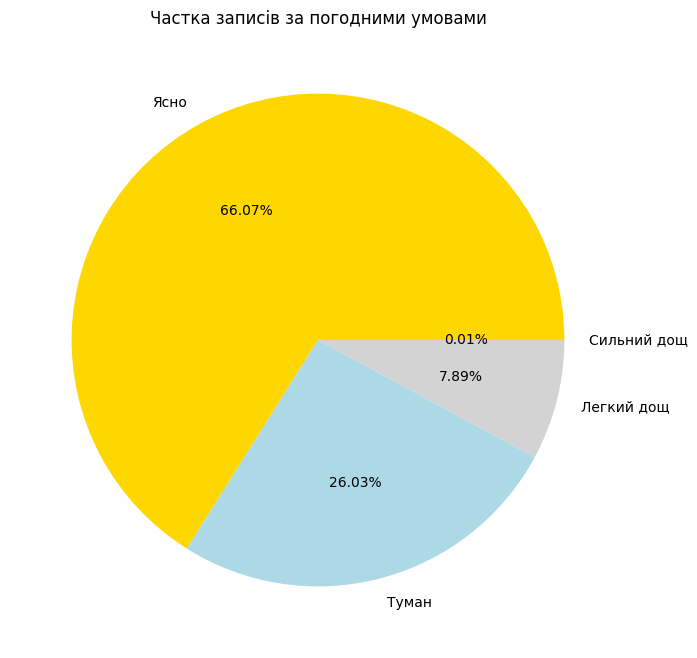

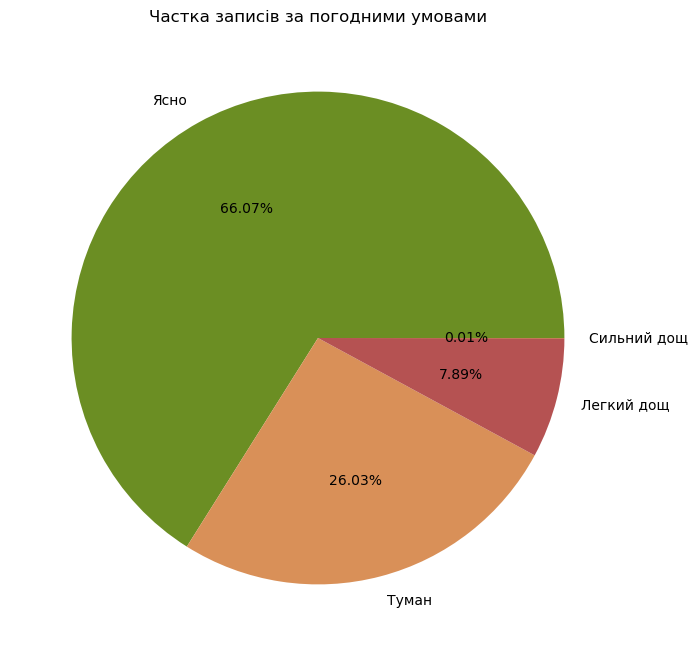

In [181]:
labels_for_weather = {1: 'Ясно', 2: 'Туман', 3: 'Легкий дощ', 4: 'Сильний дощ'}

daily_weather = df['weather'].value_counts().sort_index()

daily_weather.index = daily_weather.index.map(labels_for_weather)

colors = ['#6B8E23', '#D99058', '#B55252', '#FFFF00']

daily_weather.plot.pie(
    figsize=(8, 8),
    autopct='%1.2f%%',
    title='Частка записів за погодними умовами',
    ylabel='',
    colors=colors
);

1. Яка погода переважає в датасеті? Переважає ясна погода.
2. Чи є дні із сильним дощем? Яка їх частка? Мала частка днів із сильним дощем - 0.01%.
3. Як ви думаєте, як погодні умови впливають на попит на оренду велосипедів? Погодні умови дуже впливають на попит на оренду велосипедів: найбільше орендують велосипеди, коли погода ясна, і найменше - коли дощ. 

## Завдання 5: Box Plot для аналізу викидів

**Завдання:**
Створіть коробковий графік (box plot) кількості орендованих велосипедів для кожного типу погоди.

Просунуте доповнення:
- Використайте горизонтальну орієнтацію.
- Позначте погодні умови не числом, а назвою на візуалізації.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. При якій погоді найбільший розкид у кількості оренди?
2. Чи є викиди (outliers) в даних? При якій погоді?
3. При якій погоді медіанне значення оренди найвище?

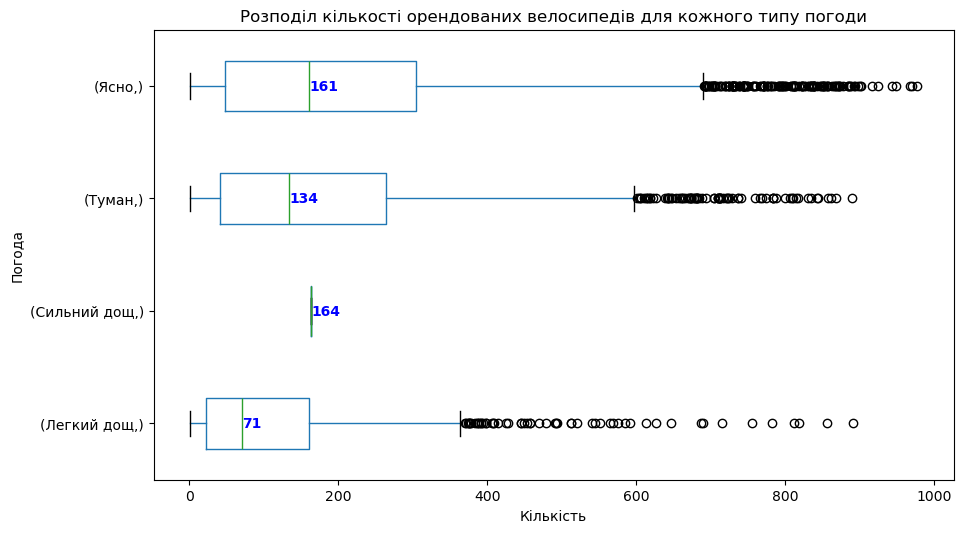

In [185]:
weather_labels = {1: 'Ясно', 2: 'Туман', 3: 'Легкий дощ', 4: 'Сильний дощ'}

df['weather_name'] = df['weather'].map(weather_labels)

ax = df.boxplot(
    column='count',
    by=['weather_name'],
    figsize=(10, 6),
    grid = False,
    vert = False
)
plt.title('Розподіл кількості орендованих велосипедів для кожного типу погоди')
plt.suptitle('')
plt.xlabel('Кількість')
plt.ylabel('Погода')

medians = df.groupby('weather_name')['count'].median()
for i, median in enumerate(medians, start=1):
    ax.text(median, i, f'{median:.0f}', va='center', ha='left', color='blue', fontweight='bold')

plt.show()

1. При якій погоді найбільший розкид у кількості оренди? При ясній погоді.
2. Чи є викиди (outliers) в даних? При якій погоді? Викиди є при ясній погоді, тумані, легкому дощу.
3. При якій погоді медіанне значення оренди найвище? Медіанне значення оренди найвище при сильному дощу - 164.

## Завдання 6: Кореляція температури та оренди (Scatter Plot)

**Завдання:**
Побудуйте діаграму розсіювання залежності між температурою (`temp`) та загальною кількістю оренди (`count`). Розфарбуйте точки за сезонами, додайте напівпрозорість (alpha=0.6).

**Увага!** За замовченням буде колір

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
- Чи є зв'язок між температурою та кількістю оренди? Який?

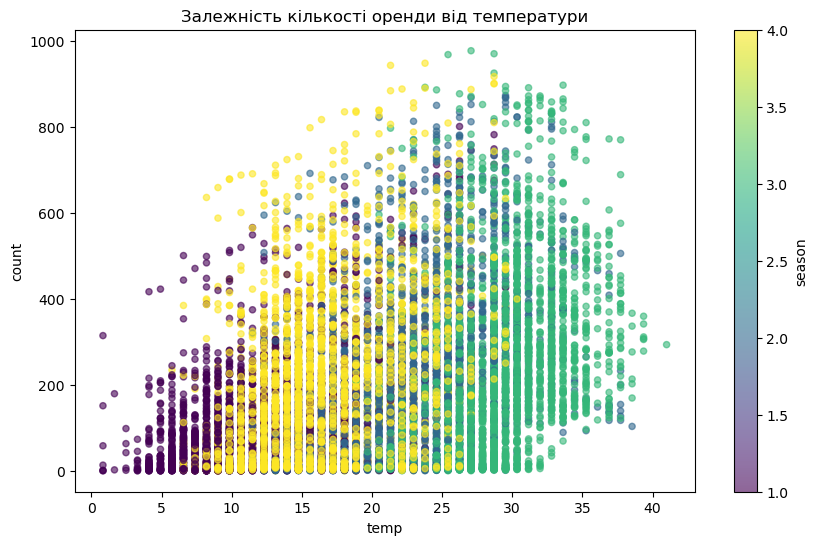

In [189]:
df.plot.scatter(
    x='temp',
    y='count',
    c='season',
    colormap='viridis',
    title='Залежність кількості оренди від температури',
    figsize=(10, 6),
    alpha=0.6
)
plt.show()

In [193]:
df[['temp', 'count']].corr(method='spearman')

,temp,count
temp,1.000000,0.407989
count,0.407989,1.000000


Коефіцієнт кореляції Пірсона вище 0.4. Отже, є помірний позитивний зв'язок.

## (Опціонально) Завдання 7: Порівняння користувачів (Stacked Bar Chart)

**Завдання:**
Ми хочемо дізнатись як по дням тижня беруть в середньому в оренду велосипеди випадкові і зареєстровані користувачі.

Створіть стовпчасту діаграму з накопиченням (bar з налаштуванням `stacked=True`), яка показує співвідношення випадкових (`casual`) та зареєстрованих (`registered`) користувачів по днях тижня за кількістю взятих ними велосипедів в оренду в середньому. Використайте різні кольори для типів користувачів.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В які дні тижня більше оренд від зареєстрованих користувачів?
2. Як ви можете пояснити таку різницю в поведінці користувачів протягом тижня?